<a href="https://colab.research.google.com/github/123Erina/Visi_Komputer_Segmentasi/blob/main/Segmentasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python matplotlib scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import sobel, prewitt
from skimage import color
from skimage.segmentation import active_contour
from skimage.filters import gaussian

Saving Jeruk.jpg to Jeruk (2).jpg


(np.float64(-0.5), np.float64(407.5), np.float64(611.5), np.float64(-0.5))

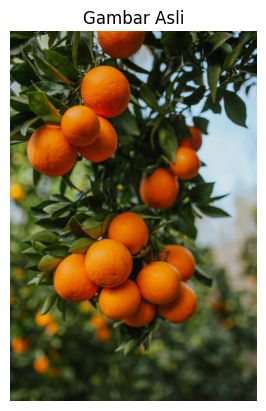

In [32]:
from google.colab import files
uploaded = files.upload()

# ganti sesuai nama file kamu
img = cv2.imread('Jeruk.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis('off')

(np.float64(-0.5), np.float64(407.5), np.float64(611.5), np.float64(-0.5))

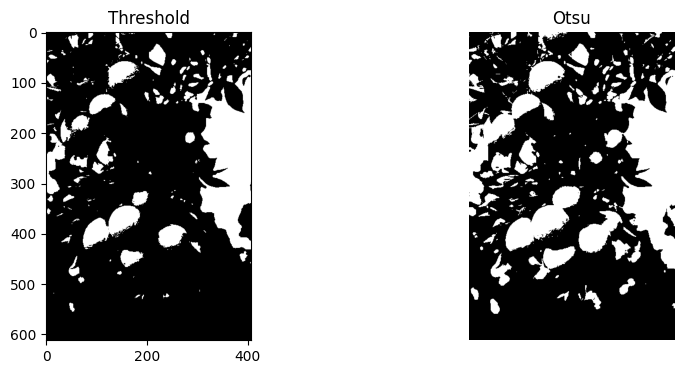

In [33]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
_, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(thresh, cmap='gray'); plt.title("Threshold")
plt.subplot(1,2,2); plt.imshow(otsu, cmap='gray'); plt.title("Otsu")
plt.axis('off')

(np.float64(-0.5), np.float64(407.5), np.float64(611.5), np.float64(-0.5))

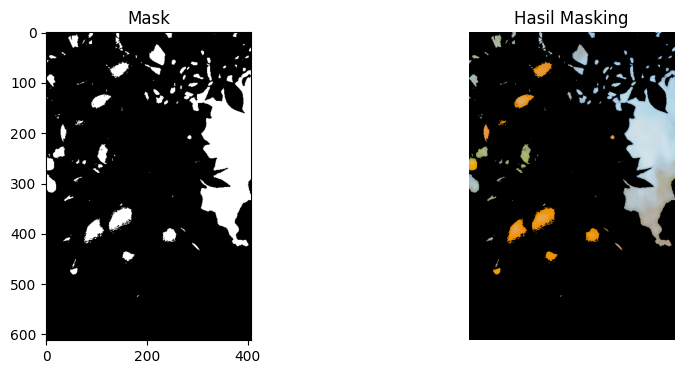

In [34]:
_, mask = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

result_mask = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(mask, cmap='gray'); plt.title("Mask")
plt.subplot(1,2,2); plt.imshow(result_mask); plt.title("Hasil Masking")
plt.axis('off')

(np.float64(-0.5), np.float64(407.5), np.float64(611.5), np.float64(-0.5))

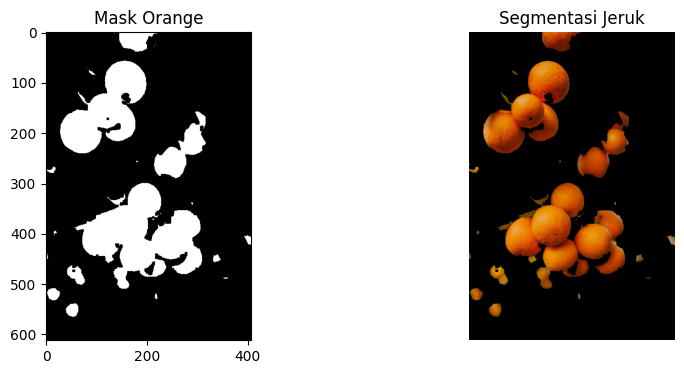

In [35]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# warna ORANGE (jeruk)
lower = np.array([5, 100, 100])
upper = np.array([20, 255, 255])

mask_orange = cv2.inRange(hsv, lower, upper)

# bersihkan noise
kernel = np.ones((5,5), np.uint8)
mask_orange = cv2.morphologyEx(mask_orange, cv2.MORPH_CLOSE, kernel)

result_orange = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_orange)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(mask_orange, cmap='gray'); plt.title("Mask Orange")
plt.subplot(1,2,2); plt.imshow(result_orange); plt.title("Segmentasi Jeruk")
plt.axis('off')

Jumlah jeruk: 9


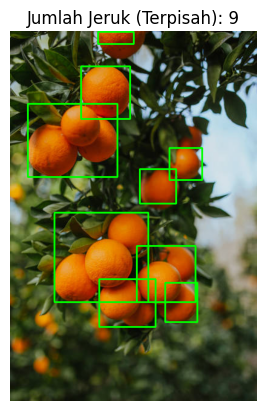

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================
# LOAD GAMBAR
# =====================
img = cv2.imread('Jeruk.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =====================
# 1. SEGMENTASI WARNA
# =====================
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower = np.array([0, 80, 80])
upper = np.array([30, 255, 255])

mask = cv2.inRange(hsv, lower, upper)

# =====================
# 2. MORPHOLOGY
# =====================
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

# =====================
# 3. DISTANCE TRANSFORM
# =====================
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

_, sure_fg = cv2.threshold(dist, 0.4 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# unknown area
unknown = cv2.subtract(sure_bg, sure_fg)

# =====================
# 4. WATERSHED
# =====================
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

markers = cv2.watershed(img, markers)

# =====================
# 5. HITUNG & TAMPILKAN
# =====================
output = img_rgb.copy()
count = 0

for label in np.unique(markers):
    if label <= 1:
        continue

    mask_obj = np.zeros(mask.shape, dtype="uint8")
    mask_obj[markers == label] = 255

    contours, _ = cv2.findContours(mask_obj, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        area = cv2.contourArea(cnt)

        if area > 300:
            count += 1
            x,y,w,h = cv2.boundingRect(cnt)
            cv2.rectangle(output, (x,y), (x+w,y+h), (0,255,0), 2)

plt.imshow(output)
plt.title(f"Jumlah Jeruk (Terpisah): {count}")
plt.axis('off')

print("Jumlah jeruk:", count)

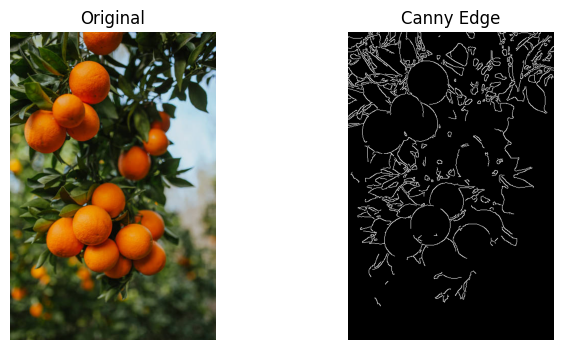

In [41]:
import cv2
import matplotlib.pyplot as plt

# baca gambar (pastikan sudah upload)
img = cv2.imread('Jeruk.jpg')

# ubah ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Canny Edge Detection
edges = cv2.Canny(gray, 100, 200)

# tampilkan hasil
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Canny Edge")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.show()